<a href="https://colab.research.google.com/github/rkimmellab/rkimmellab.github.io/blob/gh-pages/OwnData_cellbender_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CellBender v0.3.0 on Google Colab

Stephen Fleming

2023.08.14

## How Google Colab works:

- This code runs on a Google Cloud virtual machine (VM)
- That VM is where the cellbender command will run
- Your data needs to be on that VM
- All necessary software needs to be installed on that VM
- All files on the VM will stay on the VM until you press "Disconnect and delete runtime". (There may also be some kind of inaction timeout.) It is the "delete runtime" part that means the disk attached to the VM (with your files and software) is gone.
- This is totally free, and you can use a GPU
    - As a consequence, Google might "bump" you off (and your kernel will restart) in favor of a paying customer
- CellBender v0.3.0 has been re-written to be tolerant to interruptions and getting "bumped off", by making use of a checkpoint file.
    - If you get "bumped" off (i.e. the kernel dies before cellbender finishes running), simply re-run the unfinished cellbender command. No need to re-install any software. No need to re-download data. It's all still there on your "runtime" (on the disk attached to the VM). So is the checkpoint file! So cellbender will automatically pick up (near) where it left off, and continue until it finishes. You can do this as many times as necessary.

## How to use this notebook:

1.   Connect to a hosted runtime that has a T4 GPU (upper right corner of window, or under the "Runtime" dropdown menu)
2.   Run the first two cells to install `condacolab`
    - the second cell will restart the jupyter notebook kernel, and this is fine: not an error
3. Start running the rest of the notebook from cell 3 (`condacolab.check()`), skipping the first two cells
4. Move your output files somewhere permanent, via `gsutil` or by copying to Google Drive

## Notes:

- This demo notebook downloads a publicly available dataset from 10x Genomics, but you can download your own data instead, via `gsutil` or by connecting to Google Drive (https://neptune.ai/blog/google-colab-dealing-with-files ;
Accessing Google Drive from Google Colab), and run cellbender on your data (you'll need to change the command to point to your dataset).
- As mentioned above, if the cellbender command does not complete before the kernel dies, or before you get interrupted (which can happen using Colab for free), simply re-run the cellbender command (no need to run any of the preceeding notebook cells), and cellbender will pick up where it left off.
- If the `nvidia-smi` command gives an error, it means you are not connected to a runtime with a GPU. Make sure you connect to a runtime with a T4 GPU (it's free, and it's the whole point of using Google Colab)
- If you are going to walk away from this notebook while it's running, or let it run overnight or something, it might be a good idea to run a `gsutil cp` command to copy your data somewhere safe before walking away.



Set up conda (for control over python version: we need python 3.7)



In [1]:
!pip install -q condacolab

In [2]:
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:11
🔁 Restarting kernel...


After running the previous cell, the kernel will die and automatically restart.  When that happens, do not re-run the above cells... continue with the cells below:

In [17]:
import condacolab
condacolab.check()

✨🍰✨ Everything looks OK!


In [18]:
!which conda

/usr/local/bin/conda


In [3]:
!conda create -y -q -n cellbender python=3.7

Channels:
 - conda-forge
Platform: linux-64
Solving environment: ...working... done

## Package Plan ##

  environment location: /usr/local/envs/cellbender

  added / updated specs:
    - python=3.7


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _openmp_mutex-4.5          |           20_gnu          28 KB  conda-forge
    ca-certificates-2026.4.22  |       hbd8a1cb_0         128 KB  conda-forge
    icu-78.3                   |       h33c6efd_0        12.1 MB  conda-forge
    ld_impl_linux-64-2.45.1    |default_hbd61a6d_102         711 KB  conda-forge
    libffi-3.4.6               |       h2dba641_1          56 KB  conda-forge
    libgcc-15.2.0              |      he0feb66_18        1017 KB  conda-forge
    libgcc-ng-15.2.0           |      h69a702a_18          27 KB  conda-forge
    libgomp-15.2.0             |      he0feb66_18         589 KB  conda-forge
    liblzma-5.8.3           

Thank you to this post:
https://stackoverflow.com/questions/62610289/conda-activate-and-conda-init-fail-to-work-in-colab-as-per-june-2020

Install cellbender

In [4]:
%%shell
eval "$(conda shell.bash hook)"
conda activate cellbender
pip install -q cellbender
cellbender

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.5/23.5 MB 70.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.5/138.5 kB 14.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.8/563.8 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.8/529.8 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
!nvidia-smi

Mon May  4 07:02:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Download an example dataset from 10x Genomics (you can download your own data here instead)

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os

# To use a file from Google Drive, you first need to mount your Google Drive (which was done in the previous cell).
# Then, you can either copy your file from Google Drive to the Colab environment or use its direct path.
# For example, if your file is located at 'My Drive/CellBender_Data/my_input_file.h5' in your Google Drive,
# you can copy it to the current directory like this:

# !cp "/content/drive/MyDrive/CellBender_Data/my_input_file.h5" .
# Then, you would modify the 'cellbender remove-background' command in cell Y75aDwF2_SbA
# to use '--input my_input_file.h5' instead of '--input 5k_pbmc_protein_v3_nextgem_raw_feature_bc_matrix.h5'.

# Alternatively, you can directly use the Google Drive path in the cellbender command in cell Y75aDwF2_SbA, like so:
# --input "/content/drive/MyDrive/CellBender_Data/my_input_file.h5"

# Make sure to skip or delete the 'wget' command in cell Ge0Lq8TY_SnJ if you are using your own data from Google Drive.


In [19]:
# Define the path to your .tz file in Google Drive
GOOGLE_DRIVE_PATH_TO_MTX_FILE = "/content/drive/MyDrive/Cellbender_Data/Sample26_raw_matrix/matrix.mtx.gz" # <<< PLEASE UPDATE THIS PATH
LOCAL_EXTRACT_DIR = "extracted_data" # Name of the local directory to extract files into

# Create the local directory
!mkdir -p "{LOCAL_EXTRACT_DIR}"

# Copy the file from Google Drive to the local directory
!cp "{GOOGLE_DRIVE_PATH_TO_MTX_FILE}" "{LOCAL_EXTRACT_DIR}/"

# Extract the .tz file (assuming .tar.gz format)
# If your file is .mtx.gz (not tarred), you might need:
!gunzip "{LOCAL_EXTRACT_DIR}/matrix.mtx.gz"
#!tar -xzf "{LOCAL_EXTRACT_DIR}/$(basename "{GOOGLE_DRIVE_PATH_TO_MTX_FILE}")" -C "{LOCAL_EXTRACT_DIR}"

print(f"Files copied and extracted to: {LOCAL_EXTRACT_DIR}/")
!ls -F {LOCAL_EXTRACT_DIR}/

gzip: extracted_data/matrix.mtx already exists; do you wish to overwrite (y or n)? y
Files copied and extracted to: extracted_data/
matrix.mtx


In [20]:
!mkdir out

mkdir: cannot create directory ‘out’: File exists


In [ ]:
%%shell
eval "$(conda shell.bash hook)"
conda activate cellbender
mkdir -p out  # Ensure the output directory exists

# Assuming the extracted data is in a directory named 'extracted_data'
# If the extraction resulted in a different sub-directory, update this path accordingly.
cellbender remove-background --cuda --input /content/drive/MyDrive/Cellbender_Data/Sample26_raw_matrix/ --output out/Sample26_out.h5

cellbender:remove-background: Command:
cellbender remove-background --cuda --input /content/drive/MyDrive/Cellbender_Data/Sample26_raw_matrix/ --output out/Sample26_out.h5
cellbender:remove-background: CellBender 0.3.0
cellbender:remove-background: (Workflow hash 9a47b5e117)
cellbender:remove-background: 2026-05-04 10:04:17
cellbender:remove-background: Running remove-background
cellbender:remove-background: Loading data from /content/drive/MyDrive/Cellbender_Data/Sample26_raw_matrix/
cellbender:remove-background: CellRanger v3 format
cellbender:remove-background: Features in dataset: 49285 Gene Expression
cellbender:remove-background: Trimming features for inference.
cellbender:remove-background: 31465 features have nonzero counts.
cellbender:remove-background: Prior on counts for cells is 505
cellbender:remove-background: Prior on counts for empty droplets is 179
cellbender:remove-background: Excluding 6267 features that are estimated to have <= 0.1 background counts in cells.
cellbe

And here I have to admit that the strategy for creating the output report seems to fail in Google Colab. The problem might be something to do with the fact that CellBender uses a jupyter notebook to create its output HTML report. And perhaps you cannot run a notebook from inside another notebook.

At this time, there is no output HTML report for a Google Colab run. You can create one yourself by running the jupyter notebook here, inputting the file names manually: https://github.com/broadinstitute/CellBender/blob/master/cellbender/remove_background/report.ipynb

I will demonstrate similar functionality below.

In [15]:
import os

# Ensure the 'out' directory exists before trying to list its contents
!mkdir -p out

# List the contents of the 'out' directory
!ls -F out/

Sample24_out_cell_barcodes.csv	Sample25_out_cell_barcodes.csv
Sample24_out_filtered.h5	Sample25_out_filtered.h5
Sample24_out.h5			Sample25_out.h5
Sample24_out.log		Sample25_out.log
Sample24_out_metrics.csv	Sample25_out_metrics.csv
Sample24_out.pdf		Sample25_out.pdf
Sample24_out_posterior.h5	Sample25_out_posterior.h5


## Congratulations!

You've successfully run CellBender v0.3.0 using a GPU.

***Copy your output files*** to a safe location! Remember that the "runtime" here is ephemeral, and will eventually evaporate, taking your output files with it. See this post for some good information about copying files in and out of Colab: https://neptune.ai/blog/google-colab-dealing-with-files

In [16]:
# copy outputs to your google drive
# Please replace 'Your_Google_Drive_Folder_Name' with the actual name of your folder in Google Drive.
!cp -r out/* "/content/drive/MyDrive/Cellbender_Data/"

I also create the output report here, since automatic creation of the HTML report is not working in Google Colab:

In [ ]:
# re-installing cellbender is probably not the best way to do this, but
# 1. we needed the conda env above to get python 3.7
# 2. I cannot figure out how to activate the cellbender conda env and run a python import in the same cell

# so I'm just re-installing cellbender without the conda env in python 3.10 or whatever Colab is running

!pip install -q cellbender

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.7/798.7 kB 12.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 76.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.2/104.2 kB 11.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 91.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 40.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 74.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 109.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 113.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 9.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from cellbender.remove_background.report import generate_summary_plots

### CellBender version 0.3.0

2023-08-14 15:11:15

# pbmc5k_out.h5

## Loaded dataset

AnnData object with n_obs × n_vars = 9054 × 33570
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_raw', 'n_cellbender'
    var: 'ambient_expression', 'feature_type', 'genome', 'gene_id', 'cellbender_analyzed', 'n_raw', 'n_cellbender'
    uns: 'cell_size_lognormal_std', 'empty_droplet_size_lognormal_loc', 'empty_droplet_size_lognormal_scale', 'swapping_fraction_dist_params', 'estimator', 'features_analyzed_inds', 'fraction_data_used_for_testing', 'learning_curve_learning_rate_epoch', 'learning_curve_learning_rate_value', 'learning_curve_test_elbo', 'learning_curve_test_epoch', 'learning_curve_train_elbo', 'learning_curve_train_epoch', 'target_false_positive_rate'
    obsm: 'cellbender_embedding'
    layers: 'raw', 'cellbender'


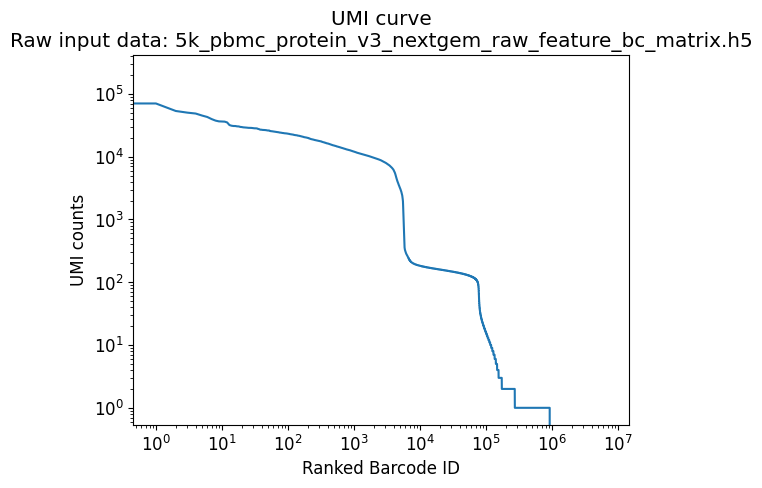

## Examine how many counts were removed in total

removed 1404352 counts from non-empty droplets
removed 2.82% of the counts in non-empty droplets


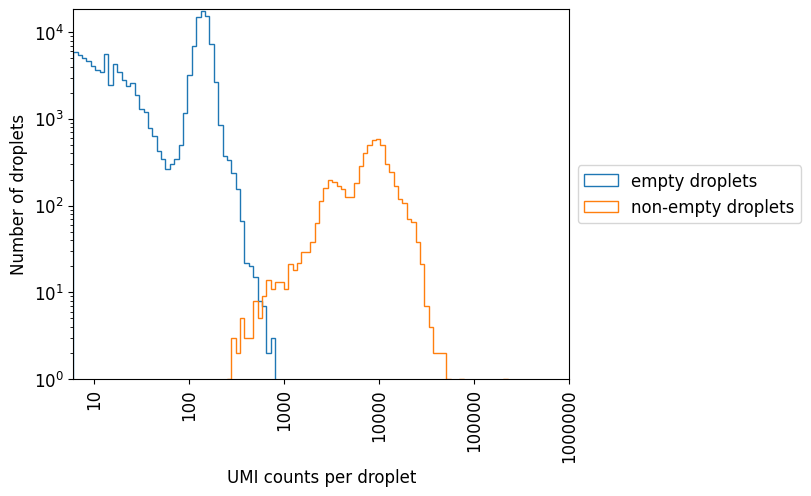

Rough estimate of expectations based on nothing but the plot above:
roughly 941735 noise counts should be in non-empty droplets
that is approximately 1.89% of the counts in non-empty droplets
with a false positive rate [FPR] of 1.0%, we would expect to remove about 2.89% of the counts in non-empty droplets


It looks like the algorithm did a great job meeting that expectation.

## Assessing convergence of the algorithm

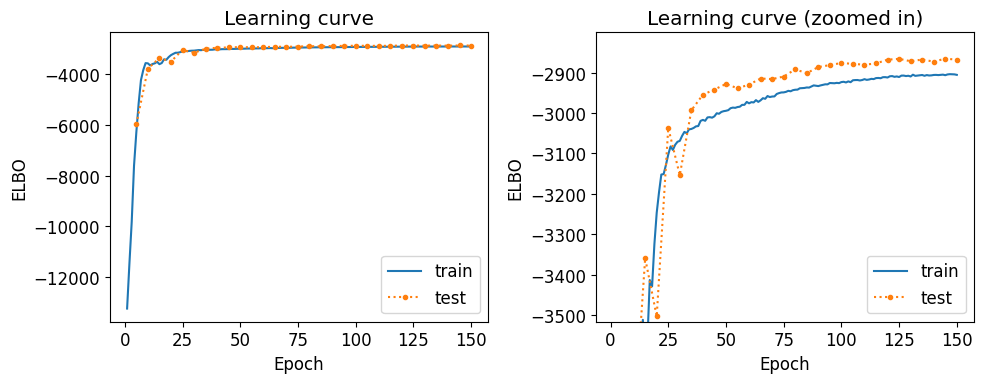

*<span style="color:gray">The learning curve tells us about the progress of the algorithm in inferring all the latent variables in our model.  We want to see the ELBO increasing as training epochs increase.  Generally it is desirable for the ELBO to converge at some high plateau, and be fairly stable.</span>*

*<span style="color:gray">What to watch out for:</span>*

*<span style="color:gray">1. large downward spikes in the ELBO (of value more than a few hundred)</span>*
*<span style="color:gray">2. the test ELBO can be smaller than the train ELBO, but generally we want to see both curves increasing and reaching a stable plateau.  We do not want the test ELBO to dip way back down at the end.</span>*
*<span style="color:gray">3. lack of convergence, where it looks like the ELBO would change quite a bit if training went on for more epochs.</span>*

**Automated assessment** --------

**Summary**:

This learning curve looks normal.

## Examine count removal per gene

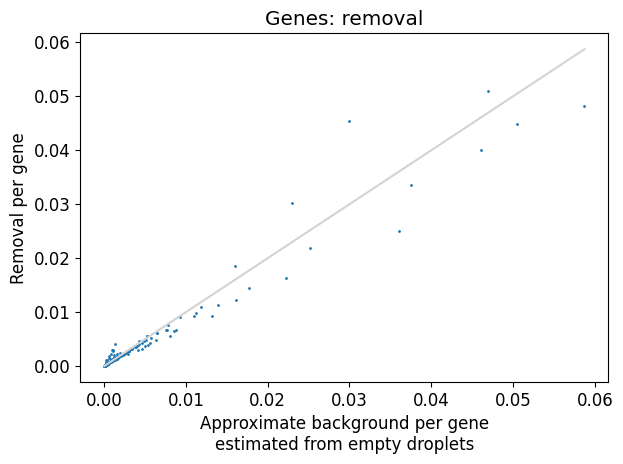

Pearson correlation coefficient for the above is 0.9791

This meets expectations.

### Table of top genes removed

Ranked by fraction removed, and excluding genes with fewer than 1268 total raw counts (90th percentile)

,ambient_expression,feature_type,genome,gene_id,cellbender_analyzed,n_raw,n_cellbender,n_removed,fraction_removed,fraction_remaining,n_raw_cells,n_cellbender_cells,n_removed_cells,fraction_removed_cells,fraction_remaining_cells
gene_name,,,,,,,,,,,,,,,
IgG2b_control_TotalSeqB,0.008340,Antibody Capture,,IgG2b,True,29270,14654,14616,0.499351,0.500649,23121,14654,8467,0.366204,0.633796
CD197_TotalSeqB,0.020673,Antibody Capture,,CD197,True,75324,39860,35464,0.470819,0.529181,60150,39860,20290,0.337323,0.662677
CD69_TotalSeqB,0.032382,Antibody Capture,,CD69,True,126468,72067,54401,0.430156,0.569844,101068,72067,29001,0.286945,0.713055
IgG1_control_TotalSeqB,0.004988,Antibody Capture,,IgG1,True,20510,11866,8644,0.421453,0.578547,16851,11866,4985,0.295828,0.704172
CD274_TotalSeqB,0.006063,Antibody Capture,,CD274,True,27278,16675,10603,0.388702,0.611298,22718,16675,6043,0.266001,0.733999
CD137_TotalSeqB,0.004707,Antibody Capture,,CD137,True,23336,15234,8102,0.347189,0.652811,19837,15234,4603,0.232041,0.767959
IgG2a_control_TotalSeqB,0.003848,Antibody Capture,,IgG2a,True,19370,12734,6636,0.342592,0.657408,16601,12734,3867,0.232938,0.767062
CD15_TotalSeqB,0.015472,Antibody Capture,,CD15,True,79385,52915,26470,0.333438,0.666562,68261,52915,15346,0.224814,0.775186
CD80_TotalSeqB,0.002772,Antibody Capture,,CD80,True,14827,10040,4787,0.322857,0.677143,12809,10040,2769,0.216176,0.783824


## Cell probabilities

The inferred posterior probability that each droplet is non-empty.

*<span style="color:gray">We sometimes write "non-empty" instead of "cell" because dead cells and other cellular debris can still lead to a "non-empty" droplet, which will have a high posterior cell probability.  But these kinds of low-quality droplets should be removed during cell QC to retain only high-quality cells for downstream analyses.</span>*

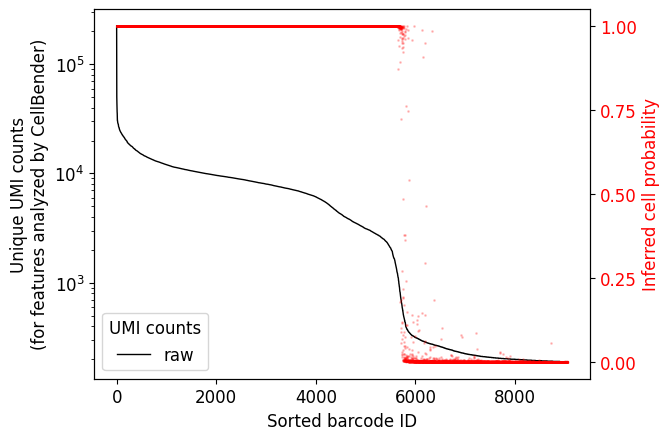

## Concordance of data before and after `remove-background`

*<span style="color:gray">The intent is to change the input data as little as possible while achieving noise removal.  These plots show general summary statistics about similarity of the input and output data.  We expect to see the data lying close to a straight line (gray).  There may be outlier genes/features, which are often those highest-expressed in the ambient RNA.</span>*

The plots here show data for inferred cell-containing droplets, and exclude the empty droplets.

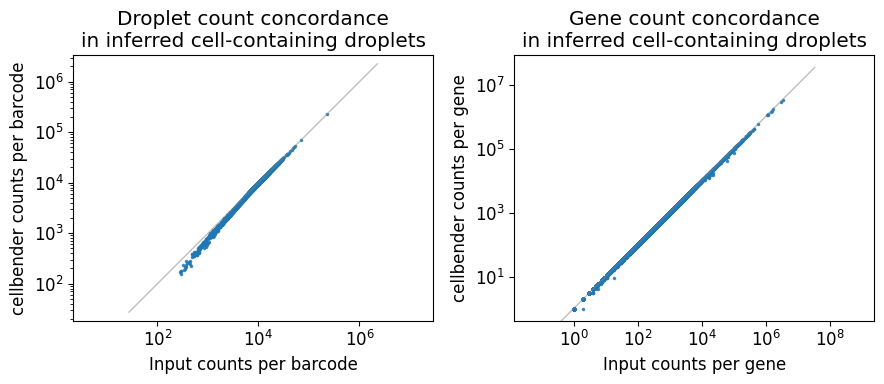

## PCA of encoded gene expression

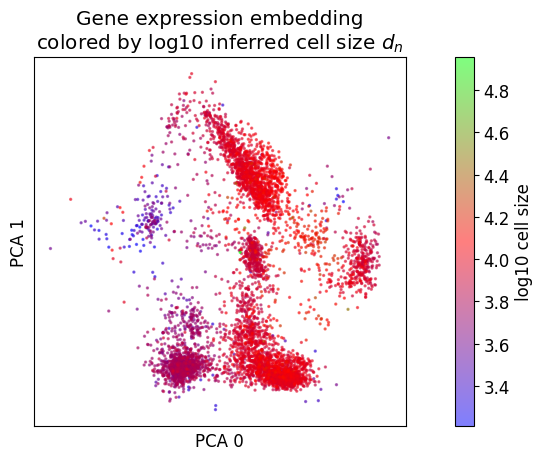

*<span style="color:gray">We are not looking for anything specific in the PCA plot of the gene expression embedding, but often we see clusters that correspond to different cell types.  If you see only a single large blob, then the dataset might contain only one cell type, or perhaps there are few counts per droplet.</span>*

# Summary of warnings:

None.

In [ ]:
# this is the full contents of the HTML report

generate_summary_plots(input_file='5k_pbmc_protein_v3_nextgem_raw_feature_bc_matrix.h5',
                       output_file='out/pbmc5k_out.h5')

The rest of this notebook is exploratory stuff for fun.

The main point is to demonstrate the use of the `load_anndata_from_input_and_output()` function from `cellbender.remove_background.downstream`

In [ ]:
from cellbender.remove_background.downstream import load_anndata_from_input_and_output

adata = load_anndata_from_input_and_output(
    input_file='5k_pbmc_protein_v3_nextgem_raw_feature_bc_matrix.h5',
    output_file='out/pbmc5k_out.h5',
)
adata

AnnData object with n_obs × n_vars = 9054 × 33570
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_cellranger', 'n_cellbender'
    var: 'ambient_expression', 'feature_type', 'genome', 'gene_id', 'cellbender_analyzed', 'n_cellranger', 'n_cellbender'
    uns: 'cell_size_lognormal_std', 'empty_droplet_size_lognormal_loc', 'empty_droplet_size_lognormal_scale', 'swapping_fraction_dist_params', 'estimator', 'features_analyzed_inds', 'fraction_data_used_for_testing', 'learning_curve_learning_rate_epoch', 'learning_curve_learning_rate_value', 'learning_curve_test_elbo', 'learning_curve_test_epoch', 'learning_curve_train_elbo', 'learning_curve_train_epoch', 'target_false_positive_rate'
    obsm: 'cellbender_embedding'
    layers: 'cellranger', 'cellbender'

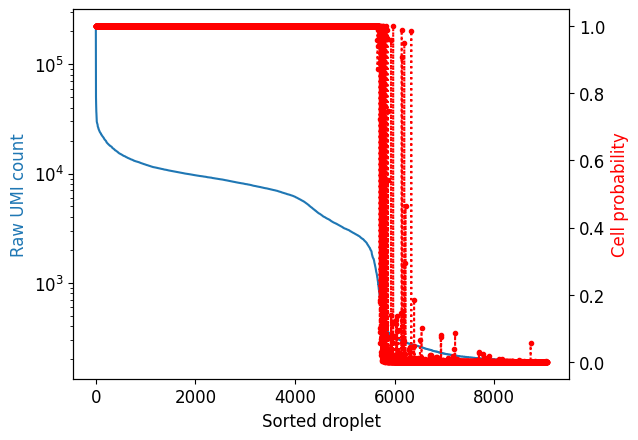

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

order = np.argsort(adata.obs['n_cellranger'].values)[::-1]

plt.semilogy(adata.obs['n_cellranger'].values[order])
plt.ylabel('Raw UMI count', color='tab:blue')
plt.xlabel('Sorted droplet')
plt.twinx()
plt.plot(adata.obs['cell_probability'].values[order], 'r.:')
plt.ylabel('Cell probability', color='r')
plt.show()

In [ ]:
adata.var.head()

,ambient_expression,feature_type,genome,gene_id,cellbender_analyzed,n_cellranger,n_cellbender
gene_name,,,,,,,
MIR1302-2HG,0.0,Gene Expression,GRCh38,ENSG00000243485,False,0,0
FAM138A,0.0,Gene Expression,GRCh38,ENSG00000237613,False,0,0
OR4F5,0.0,Gene Expression,GRCh38,ENSG00000186092,False,0,0
AL627309.1,0.0,Gene Expression,GRCh38,ENSG00000238009,False,22,22
AL627309.3,0.0,Gene Expression,GRCh38,ENSG00000239945,False,0,0


In [ ]:
adata.var['fraction_removed'] = (adata.var['n_cellranger'] - adata.var['n_cellbender']) / (adata.var['n_cellranger'] + 0.01)

In [ ]:
adata.var[adata.var['n_cellranger'] > 5000].sort_values(by='fraction_removed', ascending=False).head(20)

,ambient_expression,feature_type,genome,gene_id,cellbender_analyzed,n_cellranger,n_cellbender,fraction_removed
gene_name,,,,,,,,
IgG2b_control_TotalSeqB,0.008340,Antibody Capture,,IgG2b,True,29270,14654,0.499351
CD197_TotalSeqB,0.020673,Antibody Capture,,CD197,True,75324,39860,0.470819
CD69_TotalSeqB,0.032382,Antibody Capture,,CD69,True,126468,72067,0.430156
IgG1_control_TotalSeqB,0.004988,Antibody Capture,,IgG1,True,20510,11866,0.421453
CD274_TotalSeqB,0.006063,Antibody Capture,,CD274,True,27278,16675,0.388701
CD137_TotalSeqB,0.004707,Antibody Capture,,CD137,True,23336,15234,0.347189
IgG2a_control_TotalSeqB,0.003848,Antibody Capture,,IgG2a,True,19370,12734,0.342591
CD15_TotalSeqB,0.015472,Antibody Capture,,CD15,True,79385,52915,0.333438
CD80_TotalSeqB,0.002772,Antibody Capture,,CD80,True,14827,10040,0.322857


In [ ]:
!pip install scanpy[leiden] scikit-misc numpy==1.23

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 67.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.0/17.0 MB 53.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 69.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 31.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.3/293.3 kB 28.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.8/233.8 kB 24.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 69.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 67.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 60.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) .

In [ ]:
import scanpy as sc

In [ ]:
adata.var_names[adata.var_names.str.startswith('MT-')]

Index(['MT-ND1', 'MT-ND2', 'MT-CO1', 'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3',
       'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-ND6', 'MT-CYB'],
      dtype='object', name='gene_name')

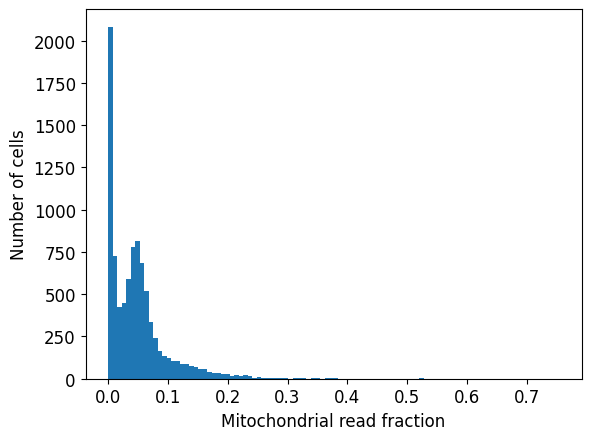

In [ ]:
adata.obs['mito_fraction'] = (
    np.array(adata.layers['cellranger'][:, adata.var_names.str.startswith('MT-')].sum(axis=1)).squeeze()
    / np.array(adata.layers['cellranger'].sum(axis=1)).squeeze()
)

plt.hist(adata.obs['mito_fraction'].values, bins=100)
plt.xlabel('Mitochondrial read fraction')
plt.ylabel('Number of cells')
plt.show()

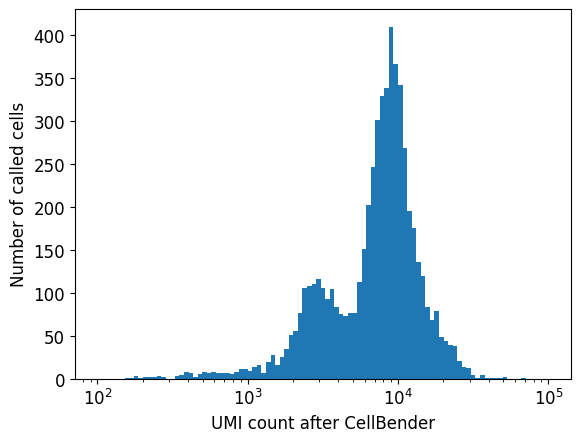

In [ ]:
plt.hist(adata[adata.obs['cell_probability'] > 0.5].obs['n_cellbender'].values, bins=np.logspace(2, 5, 100))
plt.xscale('log')
plt.xlabel('UMI count after CellBender')
plt.ylabel('Number of called cells')
plt.show()

In [ ]:
# the simplest possible cell QC: you probably want to do a much more careful job on real datasets

adata = adata[
    (adata.obs['cell_probability'] > 0.5)
    & (adata.obs['mito_fraction'] < 0.1)
    & (adata.obs['n_cellbender'] > 1000)
].copy()

/usr/local/lib/python3.10/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
adata.var_names_make_unique()

In [ ]:
adata

AnnData object with n_obs × n_vars = 4631 × 33570
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_cellranger', 'n_cellbender', 'mito_fraction'
    var: 'ambient_expression', 'feature_type', 'genome', 'gene_id', 'cellbender_analyzed', 'n_cellranger', 'n_cellbender', 'fraction_removed'
    uns: 'cell_size_lognormal_std', 'empty_droplet_size_lognormal_loc', 'empty_droplet_size_lognormal_scale', 'swapping_fraction_dist_params', 'estimator', 'features_analyzed_inds', 'fraction_data_used_for_testing', 'learning_curve_learning_rate_epoch', 'learning_curve_learning_rate_value', 'learning_curve_test_elbo', 'learning_curve_test_epoch', 'learning_curve_train_elbo', 'learning_curve_train_epoch', 'target_false_positive_rate'
    obsm: 'cellbender_embedding'
    layers: 'cellranger', 'cellbender'

In [ ]:
adata.X = adata.layers['cellbender'].copy()
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat_v3')
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.tl.pca(adata, use_highly_variable=True)
sc.pp.neighbors(adata, use_rep='X_pca')
sc.tl.umap(adata)

/usr/local/lib/python3.10/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/usr/local/lib/python3.10/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/usr/local/lib/python3.10/site-packages/umap/distances.py:1086: NumbaDeprecationWarning: The 'nopython' keyword argume

In [ ]:
sc.tl.leiden(adata, resolution=0.6)

/usr/local/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


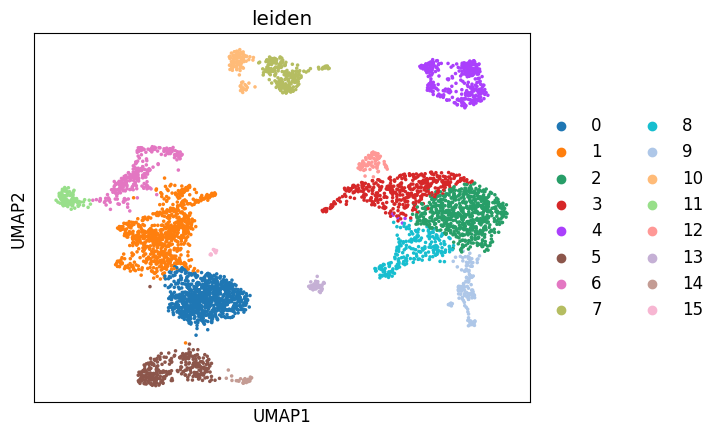

In [ ]:
sc.pl.embedding(adata, basis='umap', color='leiden')

In [ ]:
feature = 'CD14_TotalSeqB'

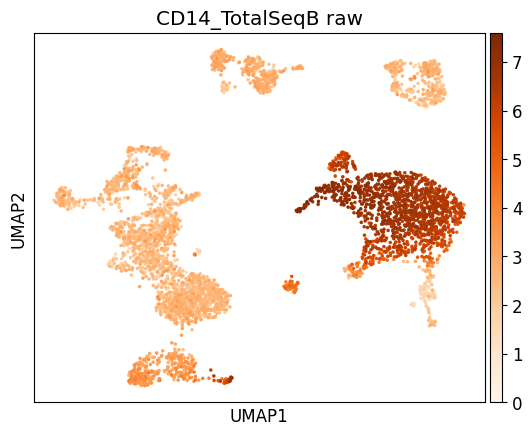

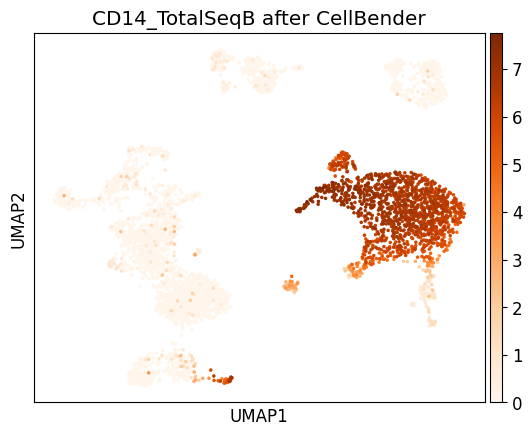

In [ ]:
adata.X = adata.layers['cellranger'].copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

sc.pl.embedding(adata, basis='umap', color=feature, color_map='Oranges', show=False)
plt.title(f'{feature} raw')
plt.show()

adata.X = adata.layers['cellbender'].copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

sc.pl.embedding(adata, basis='umap', color='CD14_TotalSeqB', color_map='Oranges', show=False)
plt.title(f'{feature} after CellBender')
plt.show()